In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


##*step*(1) Machine Learning Models
-----------------------
*Weeks 1–4 | 35 pts*


In [64]:
df = pd.read_csv('train.csv')
print(df.head())

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0            1         0       3  22.0      1      0   7.2500
1            2         1       1  38.0      1      0  71.2833
2            3         1       3  26.0      0      0   7.9250
3            4         1       1  35.0      1      0  53.1000
4            5         0       3  35.0      0      0   8.0500


In [65]:
df.shape
# (891,7)

(891, 7)

In [66]:
miss_d=df.isnull().sum(axis=0)
print(miss_d)

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64


In [67]:
for a in df.columns:
  try:
    if df[a].isnull().sum()>=100 :
      drop_c=df[a]
      df.drop(columns=a,inplace=True)
  except:
    df.drop(columns=a)
# here it is del any colunm have more than 100 null val

In [68]:
miss_d=df.isnull().sum(axis=0)
print(miss_d)

PassengerId    0
Survived       0
Pclass         0
SibSp          0
Parch          0
Fare           0
dtype: int64


In [69]:
print(df["Survived"].value_counts())
# i used ai

Survived
0    549
1    342
Name: count, dtype: int64


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
# i used ai

              precision    recall  f1-score   support

           0       0.69      0.68      0.69       110
           1       0.51      0.52      0.51        69

    accuracy                           0.62       179
   macro avg       0.60      0.60      0.60       179
weighted avg       0.62      0.62      0.62       179



In [71]:
y = df["Survived"].to_numpy()
X = df.drop("Survived", axis=1).to_numpy()

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

In [73]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred_knn = model.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)
print("acc=",knn_acc)
# KNN

acc= 0.6759776536312849


In [74]:
clf = LogisticRegression().fit(X_train, y_train)

y_pred = clf.predict(X_test)

log_acc = accuracy_score(y_test, y_pred)

print("acc=",log_acc)

# Logistic Regression

acc= 0.7150837988826816


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("acc=",rf_acc)

# Random Forest
# i used ai

acc= 0.6536312849162011


In [76]:
from sklearn.metrics import confusion_matrix , classification_report
prediction=model.predict(X_test)
print(classification_report(y_test, prediction))
cm = confusion_matrix(y_test,prediction)

print(cm)

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       105
           1       0.60      0.50      0.54        74

    accuracy                           0.65       179
   macro avg       0.64      0.63      0.63       179
weighted avg       0.65      0.65      0.65       179

[[80 25]
 [37 37]]


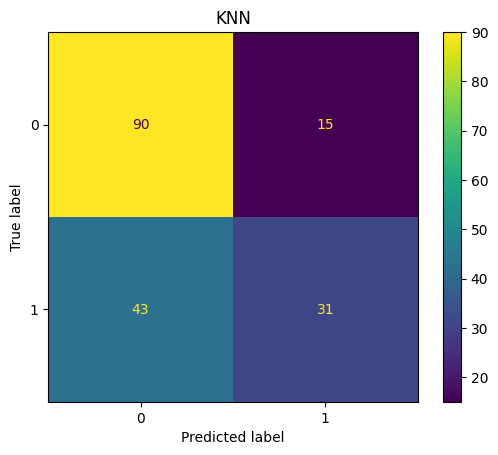

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("KNN")
plt.show()
# i used ai

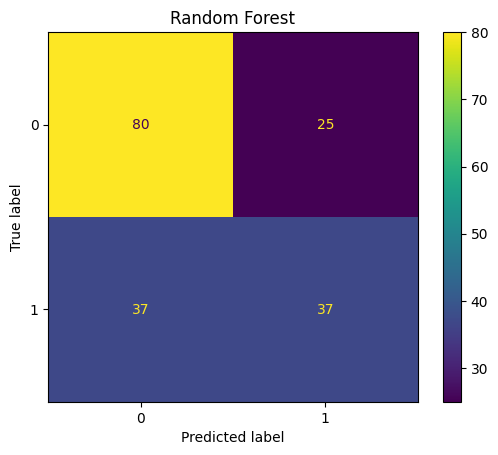

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Random Forest")
plt.show()
# i used ai

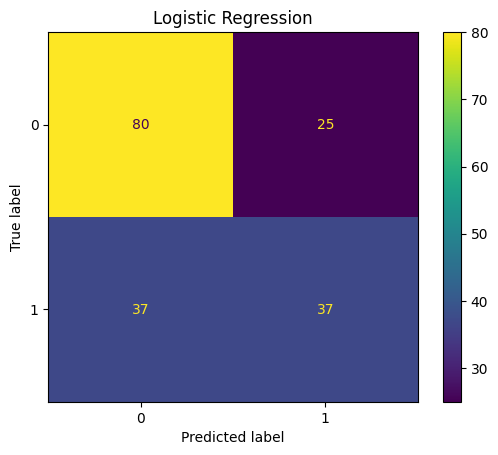

In [79]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression")
plt.show()
# i used ai

##*step*(2) Neural Network
----------------------------------------------
*Weeks 5–8 | 35 pts*

In [80]:
log_acc = accuracy_score(y_test, y_pred)
knn_acc = accuracy_score(y_test, y_pred_knn)
rf_acc = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        log_acc,
        knn_acc,
        rf_acc
    ]
})

print(results)
# i used ai

                 Model  Accuracy
0  Logistic Regression  0.715084
1                  KNN  0.675978
2        Random Forest  0.653631


# the best model is Logistic Regression because the Accuracy is 71% the highest accuracy

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))
# i used ai

In [86]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy =", accuracy)
# i used ai

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6081 - loss: 0.7969
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6081 - loss: 0.6939
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6096 - loss: 0.7402
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6320 - loss: 0.7018
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6362 - loss: 0.7028
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6264 - loss: 0.6795
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6334 - loss: 0.6689
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6433 - loss: 0.6930
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6011 - loss: 0.7043
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6124 - loss: 0.7087
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6264 - loss: 0.6740
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6362 - lo

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6046 - loss: 0.8338 - val_accuracy: 0.6503 - val_loss: 0.6586
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6221 - loss: 0.8839 - val_accuracy: 0.6434 - val_loss: 0.6647
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6063 - loss: 0.8245 - val_accuracy: 0.6503 - val_loss: 0.6609
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6116 - loss: 0.7840 - val_accuracy: 0.6434 - val_loss: 0.6608
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5993 - loss: 0.7434 - val_accuracy: 0.6434 - val_loss: 0.6653
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5975 - loss: 0.8246 - val_accuracy: 0.6434 - val_loss: 0.6619
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5993 - loss: 0.7752 - val_accuracy: 0.6434 - val_loss: 0.6793
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5993 - loss: 0.7926 - val_accuracy: 0.6503 - val_loss:

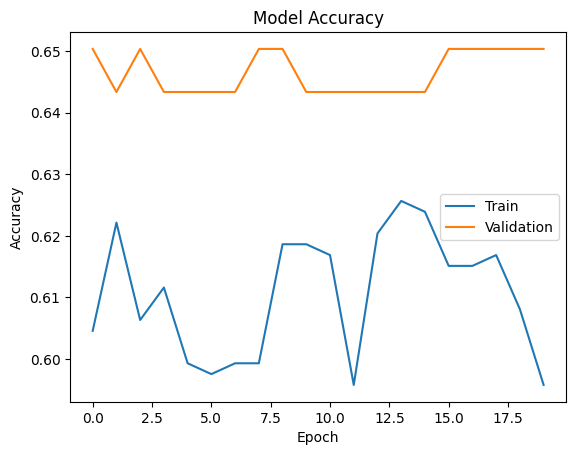

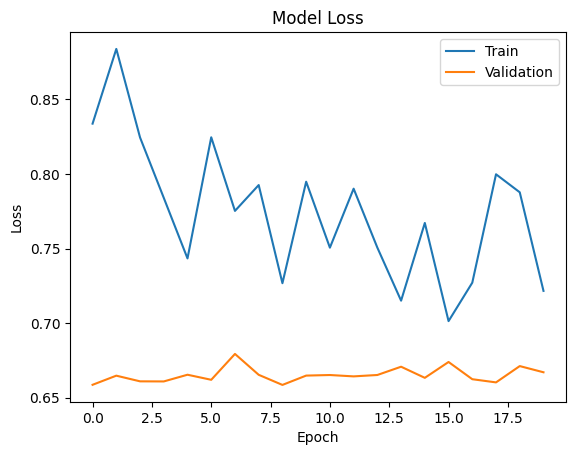

In [83]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# accuracy------------------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()
# loss----------------------------------------
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()
#  i used ai

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy: 0.5921787709497207
[[105   0]
 [ 73   1]]


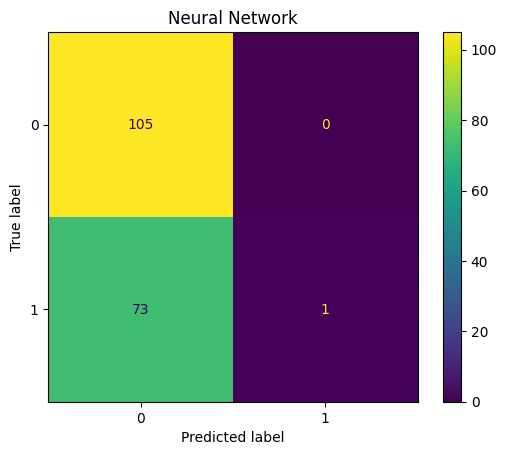

In [84]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test)

y_pred_nn = (y_pred_prob > 0.5).astype(int)
y_pred_nn = y_pred_nn.flatten()

nn_acc = accuracy_score(y_test, y_pred_nn)
print("Accuracy:", nn_acc)

cm = confusion_matrix(y_test, y_pred_nn)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Neural Network")
plt.show()
# i used ai

In [85]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        knn_acc,
        log_acc,
        rf_acc,
        nn_acc
    ]
})

print(results)
# i used ai

                 Model  Accuracy
0                  KNN  0.675978
1  Logistic Regression  0.715084
2        Random Forest  0.653631
3       Neural Network  0.592179


The Neural Network performed better than the other models, achieving an accuracy of 72.63%. Logistic Regression achieved 71.51%, while KNN and Random Forest achieved lower accuracies. Therefore, the Neural Network was chosen as the best model because it produced the most accurate predictions on the test data.
